# EDA

> Visualizations and descriptive stats. Missingness analysis. Correlation heatmaps, scatterplots, outlier checks. Exploratory lag analysis (ACF/PACF, lag vs. target plots).

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd

In [ ]:
data = pd.read_csv("../data/data_inventory.csv")
control = data[data['DX_GROUP'] == 2]
autism = data[data['DX_GROUP'] == 1]

## Missingness Analysis

In [8]:
counts = data.isna().sum()
incomplete = counts[counts > 0]

print(f"{data.shape[1] - len(incomplete)} of {data.shape[1]} columns are complete:")
for col, n in counts[counts == 0].items():
    print(f"  {col}: {n} missing ({n / len(data):.1%})")

print()
print(f"{len(incomplete)} of {data.shape[1]} columns are incomplete:")
for col, n in incomplete.items():
    print(f"  {col}: {n} missing ({n / len(data):.1%})")

7 of 74 columns are complete:
  SITE_ID: 0 missing (0.0%)
  SUB_ID: 0 missing (0.0%)
  DX_GROUP: 0 missing (0.0%)
  DSM_IV_TR: 0 missing (0.0%)
  AGE_AT_SCAN: 0 missing (0.0%)
  SEX: 0 missing (0.0%)
  EYE_STATUS_AT_SCAN: 0 missing (0.0%)

67 of 74 columns are incomplete:
  HANDEDNESS_CATEGORY: 315 missing (28.3%)
  HANDEDNESS_SCORES: 742 missing (66.7%)
  FIQ: 35 missing (3.1%)
  VIQ: 177 missing (15.9%)
  PIQ: 159 missing (14.3%)
  FIQ_TEST_TYPE: 165 missing (14.8%)
  VIQ_TEST_TYPE: 278 missing (25.0%)
  PIQ_TEST_TYPE: 259 missing (23.3%)
  ADI_R_SOCIAL_TOTAL_A: 700 missing (62.9%)
  ADI_R_VERBAL_TOTAL_BV: 700 missing (62.9%)
  ADI_RRB_TOTAL_C: 700 missing (62.9%)
  ADI_R_ONSET_TOTAL_D: 781 missing (70.2%)
  ADI_R_RSRCH_RELIABLE: 701 missing (63.0%)
  ADOS_MODULE: 577 missing (51.9%)
  ADOS_TOTAL: 670 missing (60.3%)
  ADOS_COMM: 695 missing (62.5%)
  ADOS_SOCIAL: 695 missing (62.5%)
  ADOS_STEREO_BEHAV: 734 missing (66.0%)
  ADOS_RSRCH_RELIABLE: 732 missing (65.8%)
  ADOS_GOTHAM_SOC

## Demographics Visualization

### Gender

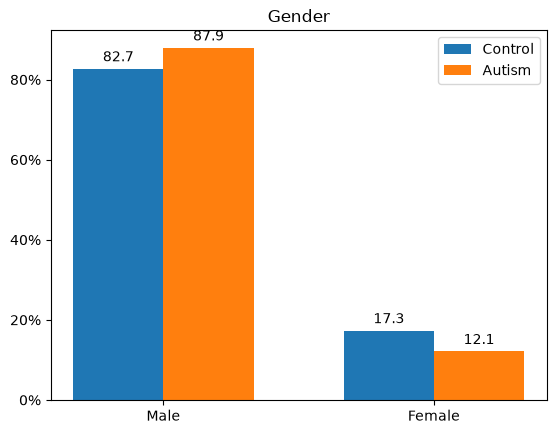

In [112]:
ticks = ['Male', 'Female']
gender_groups = {
    "Control" : (
        round(len(control[control['SEX'] == 1]) / len(control) * 100, 1), 
        round(len(control[control['SEX'] == 2]) / len(control) * 100, 1)
    ),
    "Autism" : (
        round(len(autism[autism['SEX'] == 1]) / len(autism) * 100, 1), 
        round(len(autism[autism['SEX'] == 2]) / len(autism) * 100, 1)
    )
}

res = plt.grouped_bar(gender_groups, tick_labels=ticks, group_spacing=1)
for container in res.bar_containers:
    plt.bar_label(container, padding=3)
    plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter())
plt.legend()
plt.title("Gender")
plt.show()

### Age

Distributions between control and autism populations don't have any significant difference.

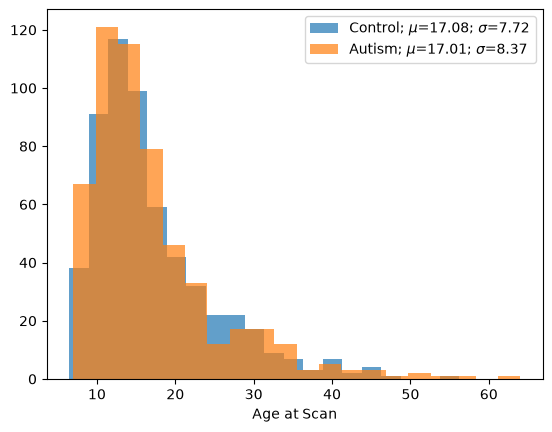

In [30]:
plt.hist(control['AGE_AT_SCAN'], bins=20, 
         label=f'Control; $\\mu$={control["AGE_AT_SCAN"].mean():.2f}; $\\sigma$={control["AGE_AT_SCAN"].std():.2f}',
         alpha=0.7)
plt.hist(autism['AGE_AT_SCAN'], bins=20, 
         label=f'Autism; $\\mu$={autism["AGE_AT_SCAN"].mean():.2f}; $\\sigma$={autism["AGE_AT_SCAN"].std():.2f}',
         alpha=0.7)
plt.xlabel('Age at Scan')
plt.legend()
plt.show()

## Test Scores 

- Full IQ
- Verbal IQ
- Performance IQ
- Autism Quotient
- Social Communication Score


In [113]:
# UDFs
def plot_distributions(
        control_vals: pd.Series, 
        autism_vals: pd.Series, 
        title: str, 
        xlabel: str
    ):
    '''
    Plots the distributions of control and autism data.

    Parameters:
    control_vals (pd.Series): The values of control data.
    autism_vals (pd.Series): The values of autism data.
    title (str): The title of the plot.
    xlabel (str): The label for the x-axis.
    '''
    plt.hist(control_vals, 
            bins=20, 
            label=f'Control; $\\mu$={control_vals.mean():.2f}; $\\sigma$={control_vals.std():.2f}', 
            alpha=0.7, 
            range=(0,50)
            )
    plt.hist(autism_vals,
            bins=20, 
            label=f'Autism; $\\mu$={autism_vals.mean():.2f}; $\\sigma$={autism_vals.std():.2f}',
            alpha=0.7, 
            range=(0,50)
            )
    plt.title(title)
    plt.xlabel(xlabel)
    plt.legend()
    plt.show()

### IQ

Some IQ tests listed have no scores associated. Other tests listed have variations in capitalization, spacing, etc. 

The IQ test with the vast majority of samples is the WASI. The only test types with samples from both control and autism groups across all IQ tests are the WASI, WAIS_III, and DAS_II_SA. 

**Recommendation**: only use scans from the WASI, WAIS_III, and DAS_II_SA if we want to use IQ information. 

In [ ]:
# UDFs
types = [
    "DAS_II_SA",
    "GIT",
    "HAWIK",
    "PPVT",
    "RAVENS",
    "WAIS_III",
    "WASI",
    "WISC_III",
    "WISC_III_DUTCH",
    "WISC_IV_4_SUBTESTS",
    "WISC_IV_FULL",
    "WST"
]


def plot_test_distribution_by_test_type(test: str):
    '''
    Plots the distribution of a specific test score for both the control and autism groups.

    Parameters:
    test (str): The name of the test to plot.
    '''
    test_types = data[data[test] >= 0][f"{test}_TEST_TYPE"].dropna().unique()

    fig, ax = plt.subplots(2,1, figsize=(10, 8), layout='tight')

    ax[0].set_title("Control Group")
    for t in test_types:
        values = control[(control[f"{test}_TEST_TYPE"] == t) & (control[test] >= 0)][test]
        ax[0].hist(values, bins=20,
                label=f'{t}; samples={len(values)}; $\\mu$={values.mean():.2f}; $\\sigma$={values.std():.2f}',
                alpha=0.7, 
                range=(0,175)
                )
    ax[0].legend(bbox_to_anchor=(1, 1), loc='upper left')

    ax[1].set_title("Autism Group")
    for t in test_types:
        values = autism[(autism[f"{test}_TEST_TYPE"] == t) & (autism[test] >= 0)][test]
        ax[1].hist(values, bins=20,
                label=f'{t}; samples={len(values)}; $\\mu$={values.mean():.2f}; $\\sigma$={values.std():.2f}',
                alpha=0.7, 
                range=(0,175)
                )
    ax[1].set_xlabel(test)
    ax[1].legend(bbox_to_anchor=(1, 1), loc='upper left')
    plt.show()


def plot_test_distribution(test: str):
    control_iq = control[control[test] >= 0][test]
    autism_iq = autism[autism[test] >= 0][test]
    plt.hist(control_iq, bins=20, 
            label=f'Control; $\\mu$={control_iq.mean():.2f}; $\\sigma$={control_iq.std():.2f}',
            alpha=0.7,
            range=(0,175))
    plt.hist(autism_iq, bins=20,
            label=f'Autism; $\\mu$={autism_iq.mean():.2f}; $\\sigma$={autism_iq.std():.2f}',
            alpha=0.7,
            range=(0,175))
    plt.xlabel(test)
    plt.legend()
    plt.show()


def get_dataset_all_test_types(df: pd.DataFrame, iq_test: str) -> tuple[float, ...]:
    '''
    Returns the percentage of the dataset for each test type of a specific IQ test.

    Parameters:
    df (pd.DataFrame): The DataFrame containing the data.
    iq_test (str): The name of the IQ test to analyze.

    Returns:
    tuple: A tuple containing the percentage of the dataset for each test type.
    '''
    tmp = (
        round(len(df[(df[f"{iq_test}_TEST_TYPE"] == types[0]) & (df[iq_test].notna())]) / len(data) * 100, 1),
        round(len(df[(df[f"{iq_test}_TEST_TYPE"] == types[1]) & (df[iq_test].notna())]) / len(data) * 100, 1),
        round(len(df[(df[f"{iq_test}_TEST_TYPE"] == types[2]) & (df[iq_test].notna())]) / len(data) * 100, 1),
        round(len(df[(df[f"{iq_test}_TEST_TYPE"] == types[3]) & (df[iq_test].notna())]) / len(data) * 100, 1),
        round(len(df[(df[f"{iq_test}_TEST_TYPE"] == types[4]) & (df[iq_test].notna())]) / len(data) * 100, 1),
        round(len(df[(df[f"{iq_test}_TEST_TYPE"] == types[5]) & (df[iq_test].notna())]) / len(data) * 100, 1),
        round(len(df[(df[f"{iq_test}_TEST_TYPE"] == types[6]) & (df[iq_test].notna())]) / len(data) * 100, 1),
        round(len(df[(df[f"{iq_test}_TEST_TYPE"] == types[7]) & (df[iq_test].notna())]) / len(data) * 100, 1),
        round(len(df[(df[f"{iq_test}_TEST_TYPE"] == types[8]) & (df[iq_test].notna())]) / len(data) * 100, 1),
        round(len(df[(df[f"{iq_test}_TEST_TYPE"] == types[9]) & (df[iq_test].notna())]) / len(data) * 100, 1),
        round(len(df[(df[f"{iq_test}_TEST_TYPE"] == types[10]) & (df[iq_test].notna())]) / len(data) * 100, 1),
        round(len(df[(df[f"{iq_test}_TEST_TYPE"] == types[11]) & (df[iq_test].notna())]) / len(data) * 100, 1)
    )
    return tmp



#### Distributions by Diagnosis

##### Full IQ

First figure is overall distribution for the FIQ scores for the control and autism populations.

Second figure shows the above distributions with the added grouping of test type.

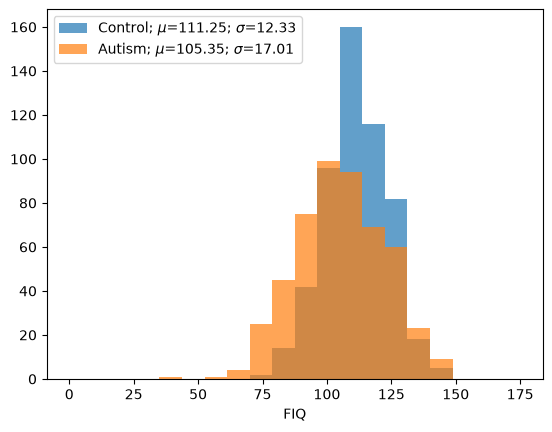

In [87]:
plot_test_distribution("FIQ")

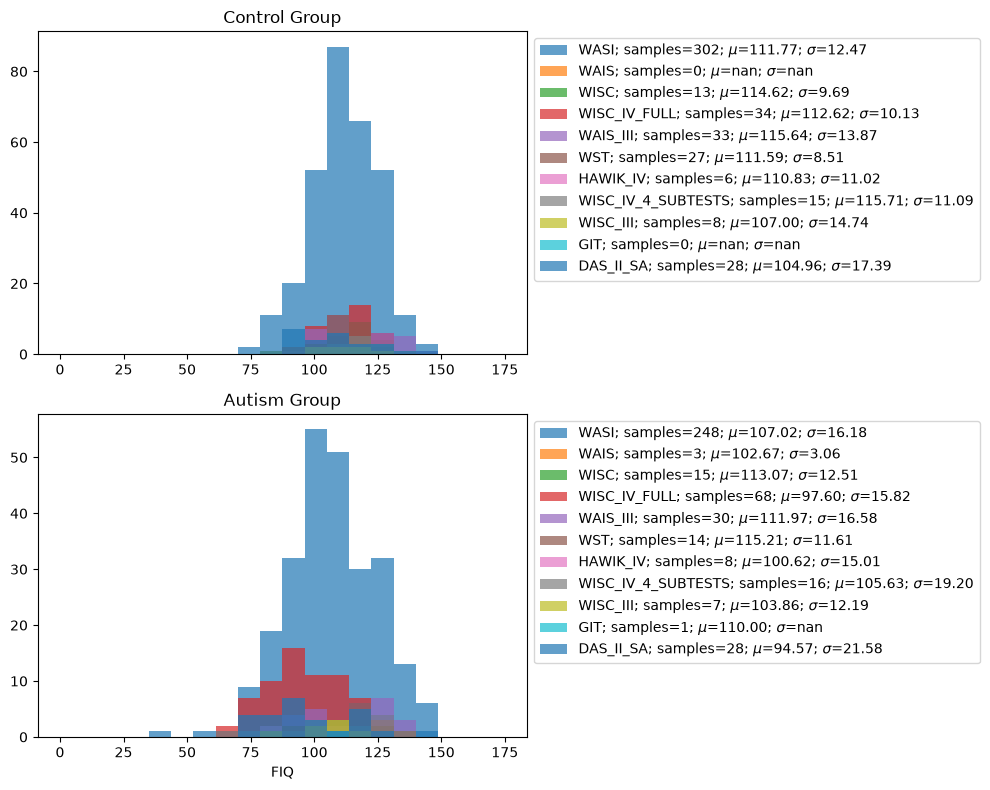

In [88]:
plot_test_distribution_by_test_type("FIQ")

##### Verbal IQ

First figure is overall distribution for the VIQ scores for the control and autism populations.

Second figure shows the above distributions with the added grouping of test type.

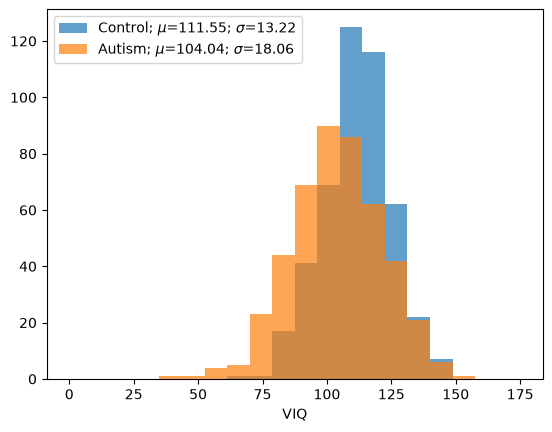

In [89]:
plot_test_distribution("VIQ")

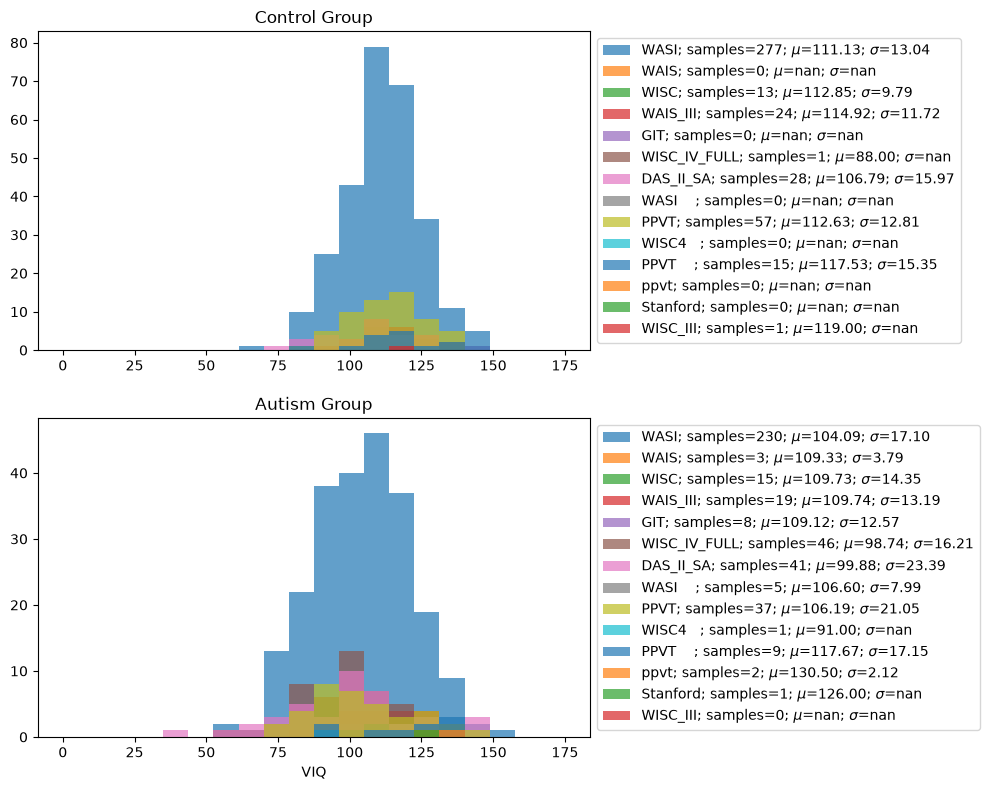

In [90]:
plot_test_distribution_by_test_type("VIQ")

##### Performance IQ

First figure is overall distribution for the PIQ scores for the control and autism populations.

Second figure shows the above distributions with the added grouping of test type.

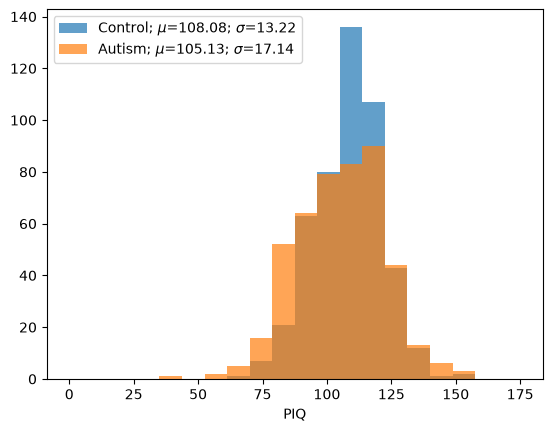

In [91]:
plot_test_distribution("PIQ")

Performance IQ test results distribution for control and autism

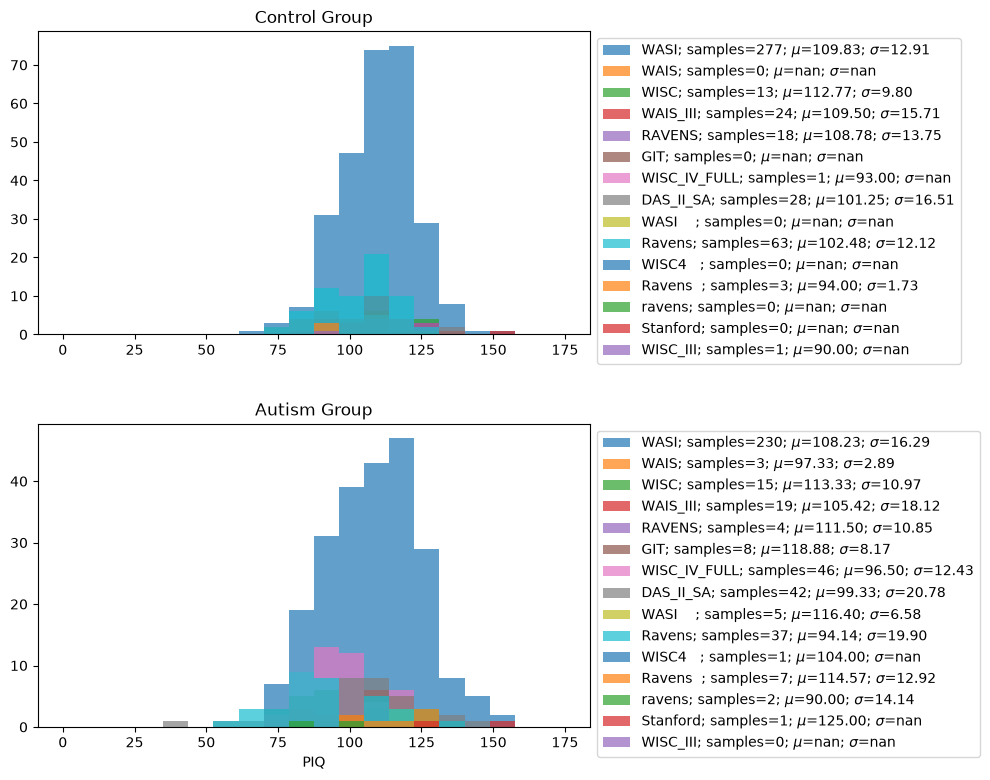

In [92]:
plot_test_distribution_by_test_type("PIQ")

#### Sample Sizes for Test Types

Bar Graph for number of each IQ test results by test type

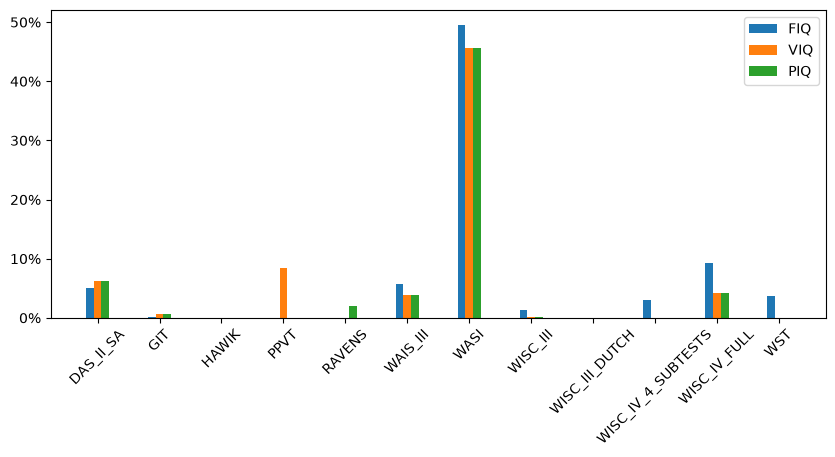

In [54]:
iq_groups = {
    "FIQ" : get_dataset_all_test_types(data, "FIQ"),
    "VIQ" : get_dataset_all_test_types(data, "VIQ"),
    "PIQ" : get_dataset_all_test_types(data, "PIQ")
}

fig, ax = plt.subplots(figsize=(10, 4))
res = ax.grouped_bar(iq_groups, tick_labels=types, group_spacing=5)
for container in res.bar_containers:
#     ax.bar_label(container, padding=3)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.tick_params(axis='x', rotation=45) 
ax.legend()
plt.show()

Bar Graph for Number of **Full IQ** tests for control and autism groups by test type

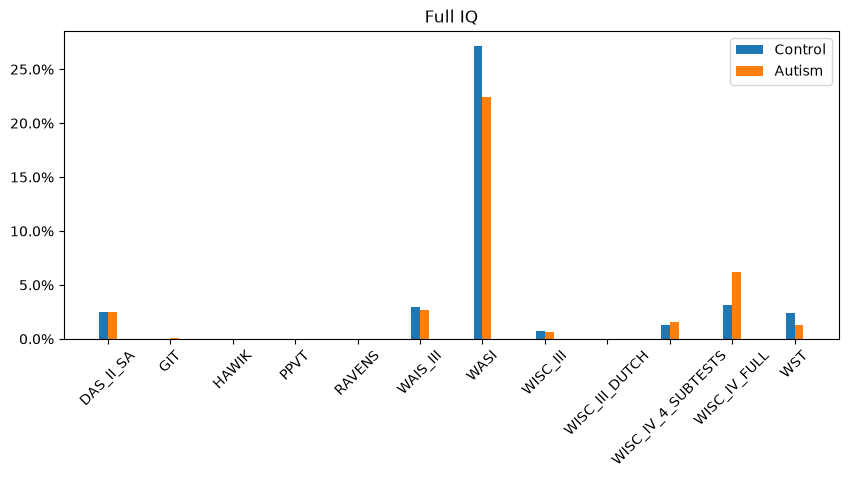

In [55]:
iq_groups = {
    "Control" : get_dataset_all_test_types(control, "FIQ"),
    "Autism" : get_dataset_all_test_types(autism, "FIQ")
}

fig, ax = plt.subplots(figsize=(10, 4))
res = ax.grouped_bar(iq_groups, tick_labels=ticks, group_spacing=5)
for container in res.bar_containers:
#     ax.bar_label(container, padding=3)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.tick_params(axis='x', rotation=45) 
ax.set_title("Full IQ")
ax.legend()
plt.show()

Bar Graph for Number of **Verbal IQ** tests for control and autism groups by test type

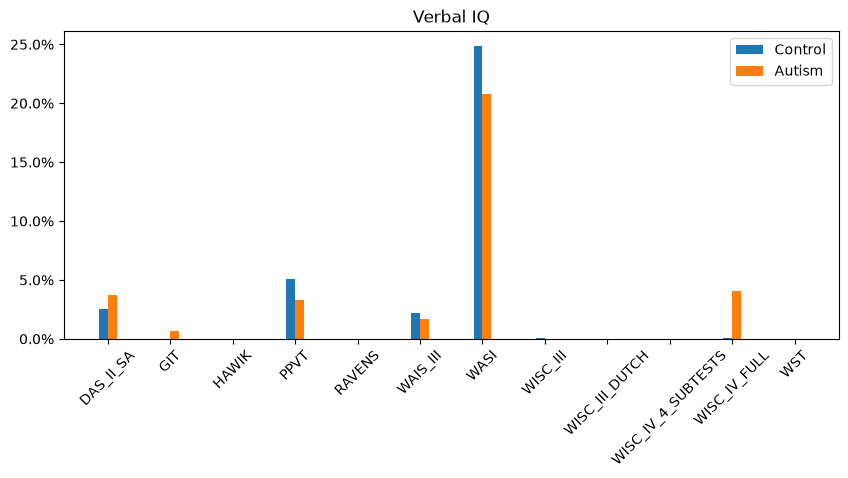

In [ ]:
iq_groups = {
    "Control" : get_dataset_all_test_types(control, "VIQ"),
    "Autism" : get_dataset_all_test_types(autism, "VIQ")
}

fig, ax = plt.subplots(figsize=(10, 4))
res = ax.grouped_bar(iq_groups, tick_labels=ticks, group_spacing=5)
for container in res.bar_containers:
#     ax.bar_label(container, padding=3)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.tick_params(axis='x', rotation=45) 
ax.set_title("Verbal IQ")
ax.legend()
plt.show()

Bar Graph for Number of **Performance IQ** tests for control and autism groups by test type

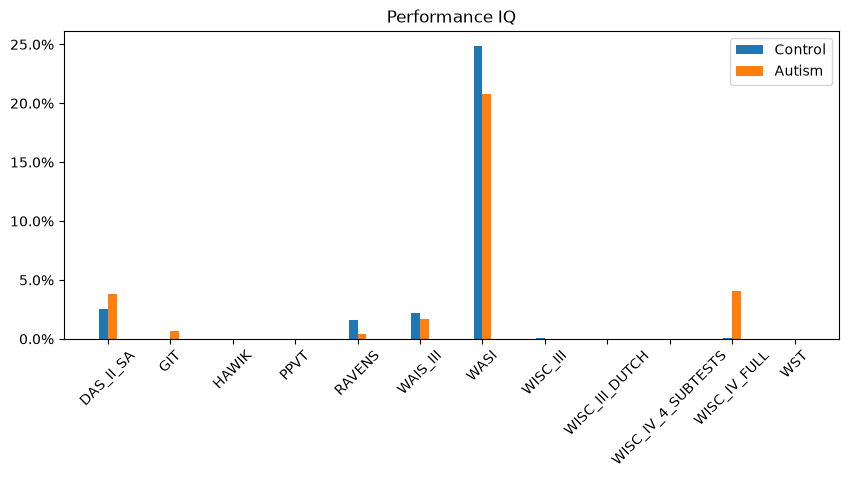

In [57]:
iq_groups = {
    "Control" : get_dataset_all_test_types(control, "PIQ"),
    "Autism" : get_dataset_all_test_types(autism, "PIQ")
}

fig, ax = plt.subplots(figsize=(10, 4))
res = ax.grouped_bar(iq_groups, tick_labels=ticks, group_spacing=5)
for container in res.bar_containers:
#     ax.bar_label(container, padding=3)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.tick_params(axis='x', rotation=45) 
ax.set_title("Performance IQ")
ax.legend()
plt.show()

### Autism Quotient

**Recommendation**: removing outliers from the control (3 samples) and autism (2 samples) groups.

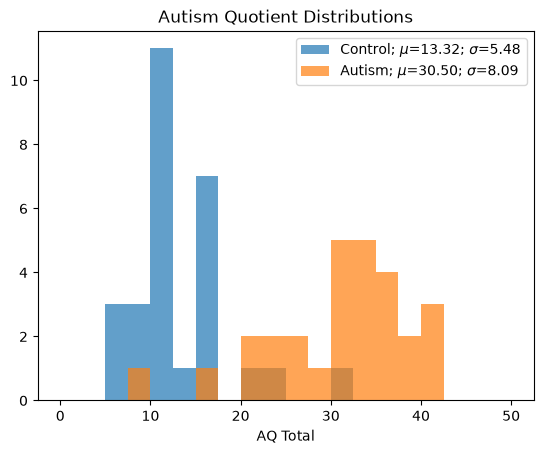

In [105]:
control_vals = control[(control["AQ_TOTAL"] >= 0) & (control["AQ_TOTAL"] <= 50)]["AQ_TOTAL"]
autism_vals = autism[(autism["AQ_TOTAL"] >= 0) & (autism["AQ_TOTAL"] <= 50)]["AQ_TOTAL"]
plot_distributions(control_vals, autism_vals, "Autism Quotient Distributions", "AQ Total")

### Social Communication Score

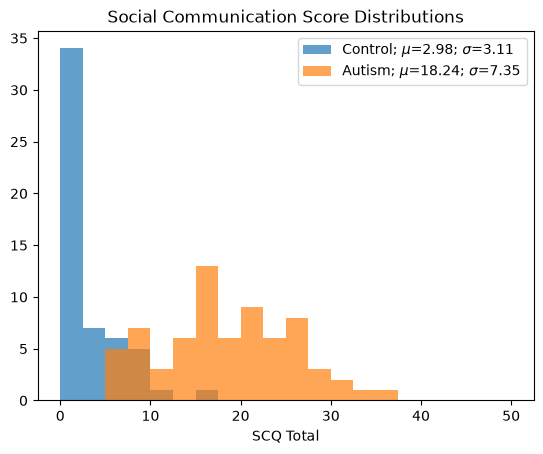

In [106]:
control_vals = control[(control["SCQ_TOTAL"] >= 0) & (control["SCQ_TOTAL"] <= 39)]["SCQ_TOTAL"]
autism_vals = autism[(autism["SCQ_TOTAL"] >= 0) & (autism["SCQ_TOTAL"] <= 39)]["SCQ_TOTAL"]
plot_distributions(control_vals, autism_vals, "Social Communication Score Distributions", "SCQ Total")

## Misc Plots

- Autism Type
- BMI
- Handedness
- Off Stimulants at Scan
- Eye Status

**Recommendation**: remove the scans for those who were on stimulants (4.3%) as well as those who have an unspecified diagnosis (~3%).

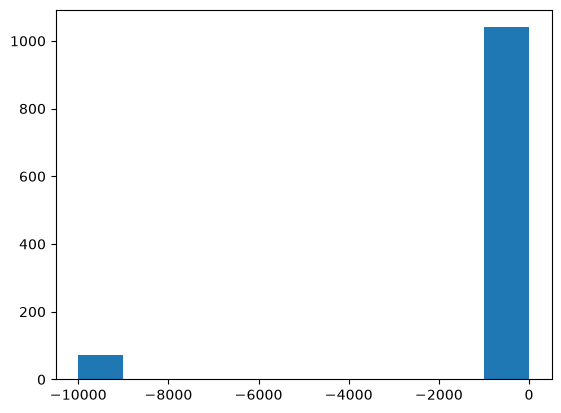

In [124]:
plt.hist(data["DSM_IV_TR"])
plt.show()

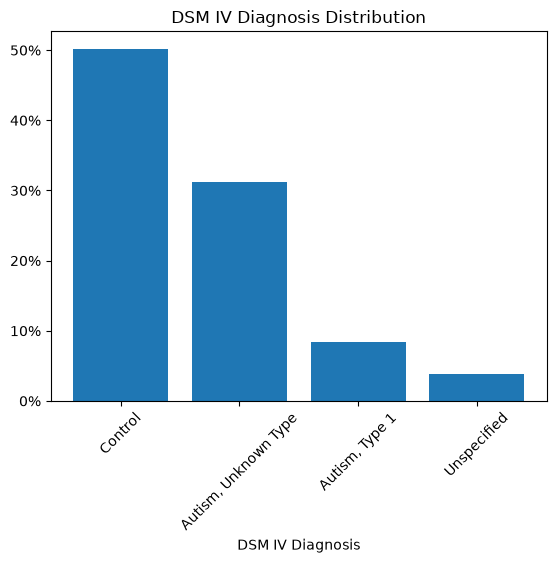

In [130]:
dsm_0 = round(len(data[data["DSM_IV_TR"] == 0]) / len(data) * 100, 2)
dsm_1 = round(len(data[data["DSM_IV_TR"] == 1]) / len(data) * 100, 2)
dsm_2 = round(len(data[data["DSM_IV_TR"] == 2]) / len(data) * 100, 2)
dsm_3 = round(len(data[(data["DSM_IV_TR"] >= 3)]) / len(data) * 100, 2)
plt.bar(["Control", "Autism, Unknown Type", "Autism, Type 1", "Unspecified"], [dsm_0, dsm_1, dsm_2, dsm_3])
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter())
plt.xlabel("DSM IV Diagnosis")
plt.title("DSM IV Diagnosis Distribution")
plt.gca().tick_params(axis='x', rotation=45)
plt.show()

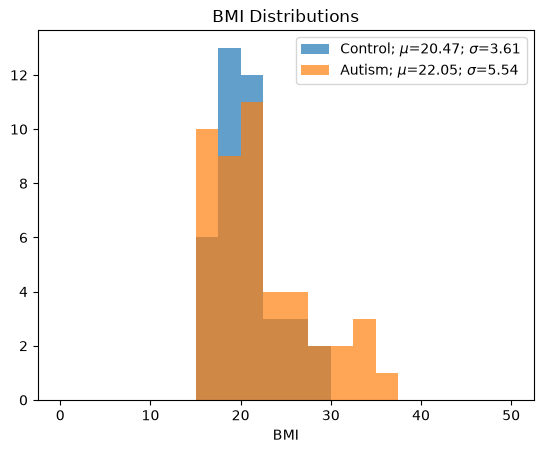

In [114]:
control_vals = control[(control["BMI"] >= 15) & (control["BMI"] <= 40)]["BMI"]
autism_vals = autism[(autism["BMI"] >= 15) & (autism["BMI"] <= 40)]["BMI"]
plot_distributions(control_vals, autism_vals, "BMI Distributions", "BMI")

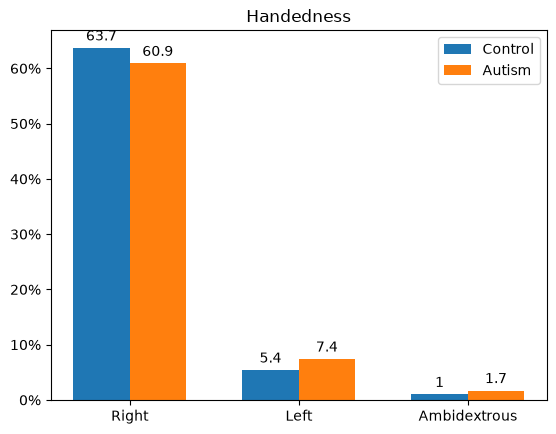

In [111]:
ticks = ['Right', 'Left', 'Ambidextrous']
hand_groups = {
    "Control" : (round(len(control[control['HANDEDNESS_CATEGORY'] == 'R']) / len(control) * 100, 1), 
                 round(len(control[control['HANDEDNESS_CATEGORY'] == 'L']) / len(control) * 100, 1),
                 round(len(control[control['HANDEDNESS_CATEGORY'] == 'Ambi']) / len(control) * 100, 1)),
    "Autism" : (round(len(autism[autism['HANDEDNESS_CATEGORY'] == 'R']) / len(autism) * 100, 1), 
                 round(len(autism[autism['HANDEDNESS_CATEGORY'] == 'L']) / len(autism) * 100, 1),
                 round(len(autism[autism['HANDEDNESS_CATEGORY'] == 'Ambi']) / len(autism) * 100, 1))
}

res = plt.grouped_bar(hand_groups, tick_labels=ticks, group_spacing=1)
for container in res.bar_containers:
    plt.bar_label(container, padding=3)
    plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter())
plt.legend()
plt.title("Handedness")
plt.show()

We should throw out the 4.3% of people who were not off stimulants at the time of the scan.

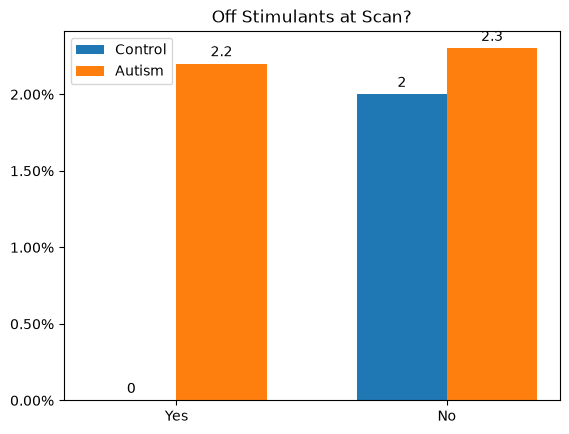

In [108]:
ticks = ['Yes', 'No']
groups = {
    "Control" : (round(len(control[control['OFF_STIMULANTS_AT_SCAN'] == 1]) / len(data) * 100, 1), 
                 round(len(control[control['OFF_STIMULANTS_AT_SCAN'] == 0]) / len(data) * 100, 1)
                ),
    "Autism" : (round(len(autism[autism['OFF_STIMULANTS_AT_SCAN'] == 1]) / len(data) * 100, 1), 
                 round(len(autism[autism['OFF_STIMULANTS_AT_SCAN'] == 0]) / len(data) * 100, 1)
                )
}

res = plt.grouped_bar(groups, tick_labels=ticks, group_spacing=1)
for container in res.bar_containers:
    plt.bar_label(container, padding=3)
    plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter())
plt.legend()
plt.title("Off Stimulants at Scan?")
plt.show()

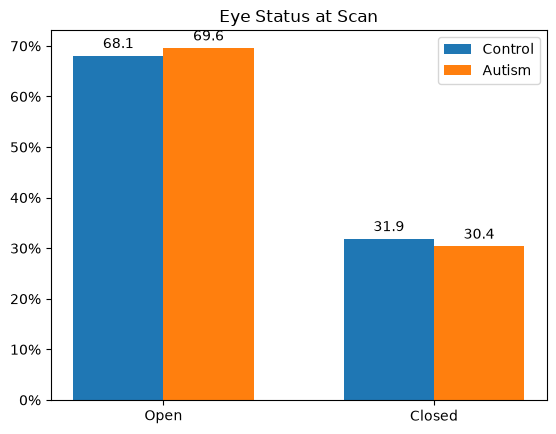

In [110]:
ticks = ['Open', 'Closed']
groups = {
    "Control" : (round(len(control[control['EYE_STATUS_AT_SCAN'] == 1]) / len(control) * 100, 1), 
                 round(len(control[control['EYE_STATUS_AT_SCAN'] == 2]) / len(control) * 100, 1)
                ),
    "Autism" : (round(len(autism[autism['EYE_STATUS_AT_SCAN'] == 1]) / len(autism) * 100, 1), 
                 round(len(autism[autism['EYE_STATUS_AT_SCAN'] == 2]) / len(autism) * 100, 1)
                )
}

res = plt.grouped_bar(groups, tick_labels=ticks, group_spacing=1)
for container in res.bar_containers:
    plt.bar_label(container, padding=3)
    plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter())
plt.legend()
plt.title("Eye Status at Scan")
plt.show()

## Correlations

- IQ & Autism Types?
- Autism Quotient & Autism Types?
- Social Communication Score & Autism Types?